# SPEDAC1 Binary Sensitivity Classification

This notebook trains and evaluates multiple classifiers (Logistic Regression, KNN, SVM, and Transformer models) on the SPEDAC1 dataset for binary sensitivity detection.

---

## 0. Environment Check

In [1]:
# Verify GPU availability — Colab should show Tesla T4
import torch
print('CUDA available:', torch.cuda.is_available())   # must be True
print('GPU device:    ', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')

CUDA available: True
GPU device:     Tesla T4


## 1. Data Loading

Parse the three WebAnno TSV splits (train / validation / test) into DataFrames.
Each sentence is extracted with its label (`Sensitive` or `Non-sensitive`).
Duplicates are removed within each split before combining.

In [2]:
# ── Parse training split ────────────────────────────────────────────────────
# WebAnno TSV format: each sentence is preceded by '#Text=<sentence>'
# and token lines carry the label in column 4 (e.g. 'Sensitive[1]').

import re
import pandas as pd

def parse_webanno_tsv(filepath):
    """Read a WebAnno TSV file and return a list of {text, label} dicts."""
    sentences = []
    current_tokens = []
    current_label  = None
    current_text   = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')

            # Skip file-level header lines
            if line.startswith('#FORMAT') or line.startswith('#T_SP'):
                continue

            # Sentence boundary — capture the full sentence text
            if line.startswith('#Text='):
                current_text = line[6:]
                continue

            # Blank line = end of sentence block; flush to list
            if line == '':
                if current_tokens and current_label and current_text:
                    sentences.append({'text': current_text, 'label': current_label})
                current_tokens, current_label, current_text = [], None, None
                continue

            # Token line: col[2] = token, col[3] = label (e.g. 'Sensitive[1]')
            parts = line.split('\t')
            if len(parts) >= 4:
                token     = parts[2]
                label_raw = parts[3]
                if label_raw != '_':
                    # Strip trailing sentence-index bracket [N]
                    current_label = re.sub(r'\[\d+\]', '', label_raw)
                current_tokens.append(token)

    return sentences

# Parse and build training DataFrame
df_train = pd.DataFrame(parse_webanno_tsv('SPEDAC1_TRAIN.tsv'))
df_train['label_binary'] = (df_train['label'] == 'Sensitive').astype(int)

print('Train — raw:')
print(df_train['label'].value_counts())
print(f'Total: {len(df_train)}')

# Remove exact-text duplicates within the training split
df_train_deduped = df_train.drop_duplicates(subset='text', keep='first')
print('\nTrain — after dedup:')
print(df_train_deduped['label'].value_counts())
print(f'Total: {len(df_train_deduped)}')

Train — raw:
label
Sensitive        5358
Non-sensitive    5325
Name: count, dtype: int64
Total: 10683

Train — after dedup:
label
Sensitive        4478
Non-sensitive    4418
Name: count, dtype: int64
Total: 8896


In [3]:
# ── Parse validation split ──────────────────────────────────────────────────
df_vali = pd.DataFrame(parse_webanno_tsv('SPEDAC1_VALI.tsv'))
df_vali['label_binary'] = (df_vali['label'] == 'Sensitive').astype(int)

print('Validation — raw:')
print(df_vali['label'].value_counts())
print(f'Total: {len(df_vali)}')

df_vali_deduped = df_vali.drop_duplicates(subset='text', keep='first')
print('\nValidation — after dedup:')
print(df_vali_deduped['label'].value_counts())
print(f'Total: {len(df_vali_deduped)}')

Validation — raw:
label
Sensitive        441
Non-sensitive    404
Name: count, dtype: int64
Total: 845

Validation — after dedup:
label
Sensitive        441
Non-sensitive    404
Name: count, dtype: int64
Total: 845


In [4]:
# ── Parse test split ────────────────────────────────────────────────────────
df_test = pd.DataFrame(parse_webanno_tsv('SPEDAC1_TEST.tsv'))
df_test['label_binary'] = (df_test['label'] == 'Sensitive').astype(int)

print('Test — raw:')
print(df_test['label'].value_counts())
print(f'Total: {len(df_test)}')

df_test_deduped = df_test.drop_duplicates(subset='text', keep='first')
print('\nTest — after dedup:')
print(df_test_deduped['label'].value_counts())
print(f'Total: {len(df_test_deduped)}')

Test — raw:
label
Non-sensitive    1132
Sensitive        1086
Name: count, dtype: int64
Total: 2218

Test — after dedup:
label
Non-sensitive    1116
Sensitive        1076
Name: count, dtype: int64
Total: 2192


## 2. Dataset Consolidation

Merge the three splits into a single DataFrame, run a final global dedup pass,
then shuffle. Cross-split overlap is checked to confirm there is no data leakage
between the original splits.

In [5]:
# ── Combine splits and perform global deduplication ─────────────────────────
# Merge the per-split deduped frames into one master DataFrame
combined_df = pd.concat(
    [df_train_deduped, df_test_deduped, df_vali_deduped],
    ignore_index=True
)

# Final global dedup — catches any sentences that appear in multiple splits
combined_df = combined_df.drop_duplicates(subset='text', keep='first')

# Shuffle so class order is random before any downstream splitting
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Cross-split overlap check ────────────────────────────────────────────────
# Ideally all three counts should be 0 (no shared sentences across splits)
train_ids = set(df_train_deduped['text'])
test_ids  = set(df_test_deduped['text'])
val_ids   = set(df_vali_deduped['text'])

print('Cross-split sentence overlap (should be 0):')
print(f'  Train ∩ Test: {len(train_ids & test_ids)}')
print(f'  Train ∩ Val:  {len(train_ids & val_ids)}')
print(f'  Test  ∩ Val:  {len(test_ids  & val_ids)}')
print(f'\nCombined dataset size: {len(combined_df)}')
print(combined_df['label'].value_counts())

# Save individual split CSVs for reference
df_train_deduped.to_csv('train.csv',      index=False)
df_test_deduped.to_csv('test.csv',        index=False)
df_vali_deduped.to_csv('validation.csv',  index=False)

Cross-split sentence overlap (should be 0):
  Train ∩ Test: 936
  Train ∩ Val:  352
  Test  ∩ Val:  196

Combined dataset size: 10531
label
Non-sensitive    5302
Sensitive        5229
Name: count, dtype: int64


## 3. Evaluation Helper

Centralised `evaluate()` function used by every model.
Computes accuracy, macro F1, weighted F1, per-class F1 for *Sensitive*, and AUC-ROC.
Results are also stored in `all_results` for the final comparison table.

In [6]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate(name, y_true, y_pred, y_prob=None):
    """
    Compute and print a full metric summary for a classifier.

    Parameters
    ----------
    name   : display name for this model
    y_true : ground-truth labels
    y_pred : predicted labels
    y_prob : predicted probabilities for the positive class (optional, for AUC)

    Returns
    -------
    dict with all metrics, appended to all_results by the caller
    """
    results = {
        'model':        name,
        'accuracy':     round(accuracy_score(y_true, y_pred) * 100, 2),
        'f1_macro':     round(f1_score(y_true, y_pred, average='macro') * 100, 2),
        'f1_weighted':  round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
        # F1 for the positive (Sensitive) class specifically
        'f1_sensitive': round(f1_score(y_true, y_pred, pos_label=1) * 100, 2),
        'auc':          round(roc_auc_score(y_true, y_prob) * 100, 2)
                        if y_prob is not None else None
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:     {results['accuracy']}%")
    print(f"  Macro F1:     {results['f1_macro']}%")
    print(f"  Weighted F1:  {results['f1_weighted']}%")
    print(f"  F1 Sensitive: {results['f1_sensitive']}%")
    if results['auc']:
        print(f"  AUC-ROC:      {results['auc']}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Non-sensitive','Sensitive'])}")
    return results

# Accumulates one dict per model; used to build the final comparison table
all_results = []

## 4. Data Exploration

Visualise class balance, sentence length distribution (word-level and character-level),
and descriptive statistics. These plots inform max_length choices for transformers
and help detect any imbalance that may affect model training.

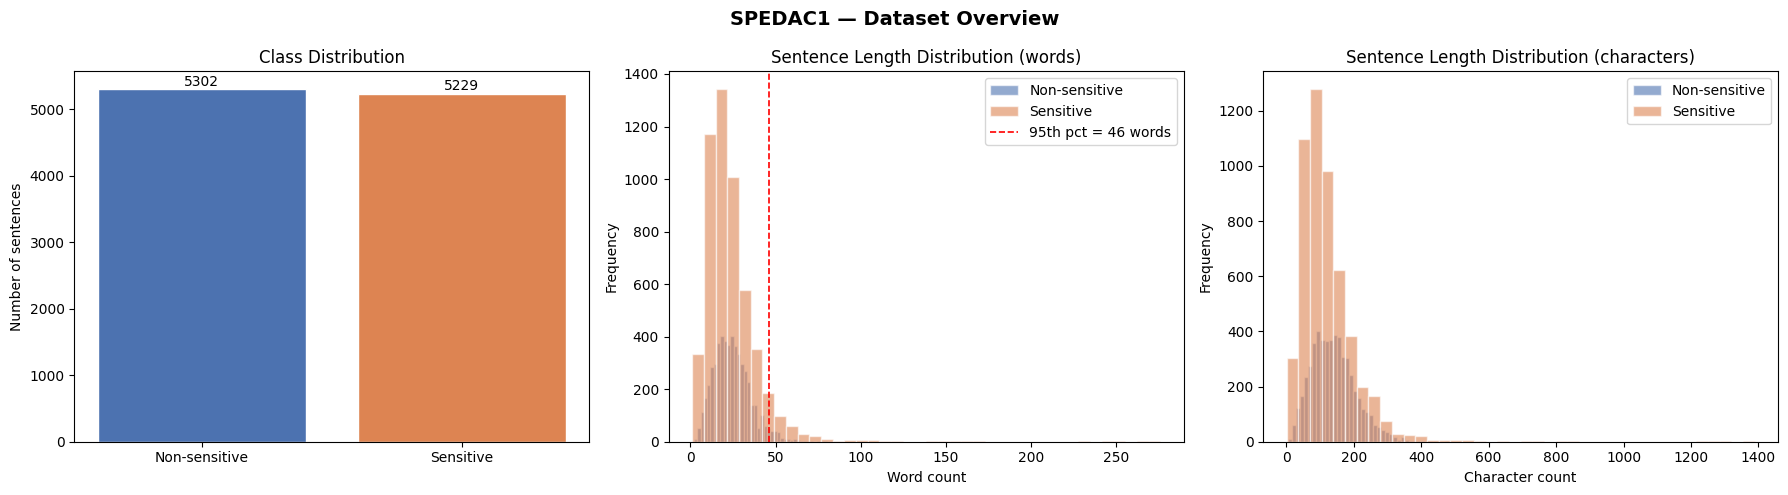


Word-count statistics per class:
                count  mean   std  min   25%   50%   75%    max
label                                                          
Non-sensitive  5302.0  24.4  10.9  2.0  16.0  23.0  31.0   80.0
Sensitive      5229.0  23.5  16.7  1.0  14.0  20.0  29.0  276.0

Character-count statistics per class:
                count   mean   std  min   25%    50%    75%     max
label                                                              
Non-sensitive  5302.0  141.3  65.7  6.0  93.0  135.0  180.0   484.0
Sensitive      5229.0  121.6  88.9  1.0  68.0  103.0  152.0  1389.0

95th percentile word count: 46
(Use this as a guide for transformer max_length)


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ── 4a. Class balance ────────────────────────────────────────────────────────
label_counts = combined_df['label'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SPEDAC1 — Dataset Overview', fontsize=14, fontweight='bold')

# Bar chart of class counts
axes[0].bar(label_counts.index, label_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of sentences')
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10)

# ── 4b. Word-count distribution per class ────────────────────────────────────
# Word count = number of whitespace-separated tokens
combined_df['word_count'] = combined_df['text'].str.split().str.len()

for label, colour in [('Non-sensitive', '#4C72B0'), ('Sensitive', '#DD8452')]:
    subset = combined_df[combined_df['label'] == label]['word_count']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label,
                 color=colour, edgecolor='white')

axes[1].set_title('Sentence Length Distribution (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Add vertical lines for 95th percentile — useful for choosing max_length
p95_words = int(np.percentile(combined_df['word_count'], 95))
axes[1].axvline(p95_words, color='red', linestyle='--', linewidth=1.2,
                label=f'95th pct = {p95_words} words')
axes[1].legend()

# ── 4c. Character-count distribution ─────────────────────────────────────────
combined_df['char_count'] = combined_df['text'].str.len()

for label, colour in [('Non-sensitive', '#4C72B0'), ('Sensitive', '#DD8452')]:
    subset = combined_df[combined_df['label'] == label]['char_count']
    axes[2].hist(subset, bins=40, alpha=0.6, label=label,
                 color=colour, edgecolor='white')

axes[2].set_title('Sentence Length Distribution (characters)')
axes[2].set_xlabel('Character count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

# ── 4d. Descriptive statistics ───────────────────────────────────────────────
print('\nWord-count statistics per class:')
print(combined_df.groupby('label')['word_count'].describe().round(1).to_string())

print('\nCharacter-count statistics per class:')
print(combined_df.groupby('label')['char_count'].describe().round(1).to_string())

print(f'\n95th percentile word count: {p95_words}')
print('(Use this as a guide for transformer max_length)')

## 5. Text Preprocessing (BOW models only)

Apply lowercase, punctuation removal, and stopword filtering to produce a
cleaned `processed` column. This is used only by the BOW vectorizer;
transformer models use the raw `text` column directly.

In [8]:
import re

# Minimal stopword list — common English function words unlikely to carry
# sensitivity signal. Tokens shorter than 3 characters are also dropped.
STOPWORDS = set("""
a an the is are was were be been being have has had do does did will would
could should may might must shall can i me my we you he she it they what
which who this that these those am of at by for with about against between
into through during before after above below to from up down in out on off
over under again further then once here there when where why how all both
each few more most other some such no nor not only own same so than too
very just don doesn didn won t s m re ve ll d
""".split())

def preprocess(text):
    """Lowercase, strip non-alpha characters, remove stopwords and short tokens."""
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)           # keep only letters
    tokens = [w for w in text.split()
              if w not in STOPWORDS and len(w) > 2]    # drop stopwords + short tokens
    return ' '.join(tokens)

combined_df['processed'] = combined_df['text'].apply(preprocess)
print(f'Sample processed text:\n  {combined_df["processed"].iloc[0]}')

Sample processed text:
  dialects basically mainly spoken means communication any rudimentary and incomplete written form


## 6. Label Encoding & Feature Preparation

Encode string labels to integers with `LabelEncoder`, then define `X` (raw text Series)
and `y` (encoded labels) ready for splitting.

In [9]:
from sklearn.preprocessing import LabelEncoder

# Fit encoder on the combined label column
# LabelEncoder assigns alphabetical order: Non-sensitive=0, Sensitive=1
le = LabelEncoder()
combined_df['label_encoded'] = le.fit_transform(combined_df['label'])

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# X is the raw text Series (the vectorizer will transform it in the next step)
X = combined_df['text']
y = combined_df['label_encoded']

print('\nClass counts (encoded):')
print(combined_df['label_encoded'].value_counts())

Label mapping: {'Non-sensitive': np.int64(0), 'Sensitive': np.int64(1)}

Class counts (encoded):
label_encoded
0    5302
1    5229
Name: count, dtype: int64


## 7. Train / Test Split

Stratified 70/30 split on the full combined dataset.
Stratification preserves the class ratio in both subsets.

In [10]:
from sklearn.model_selection import train_test_split

# Stratify ensures the Sensitive/Non-sensitive ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print('\nTest set class distribution:')
print(y_test.value_counts())

Train size: 7371
Test size:  3160

Test set class distribution:
label_encoded
0    1591
1    1569
Name: count, dtype: int64


## 8. BOW Vectorisation

Unigram Bag-of-Words using `CountVectorizer`.
The vectorizer is **fitted on the training set only** — applying `transform` to the test
set prevents vocabulary leakage.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Unigram BOW — replicates the baseline setting from the SPEDAC1 paper
vectorizer = CountVectorizer(ngram_range=(1, 1))

# fit_transform on train: learns vocabulary and encodes
X_train = vectorizer.fit_transform(X_train)

# transform only on test: uses the training vocabulary — NO fit
# Fitting on test would leak test-set vocabulary into the model
X_test  = vectorizer.transform(X_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Train matrix:    {X_train.shape}')
print(f'Test matrix:     {X_test.shape}')

Vocabulary size: 16891
Train matrix:    (7371, 16891)
Test matrix:     (3160, 16891)


## 9. Logistic Regression (no regularisation tuning)

Baseline LR with default `C=1.0`. Provides a reference point before cross-validated
regularisation is applied.

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1591
           1       0.91      0.90      0.90      1569

    accuracy                           0.91      3160
   macro avg       0.91      0.91      0.91      3160
weighted avg       0.91      0.91      0.91      3160

F1 Macro: 0.9050431692984133


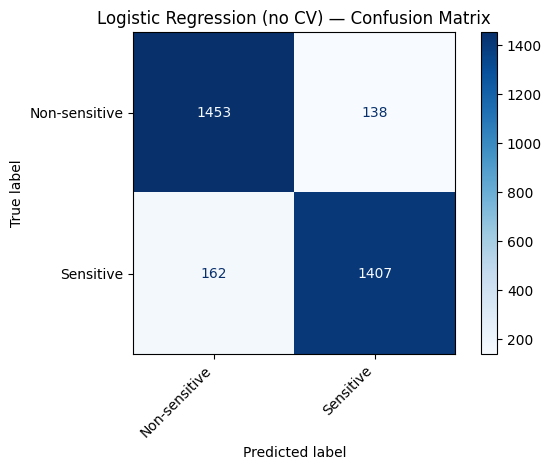


  Logistic Regression (no CV)
  Accuracy:     90.51%
  Macro F1:     90.5%
  Weighted F1:  90.51%
  F1 Sensitive: 90.37%
  AUC-ROC:      95.48%

               precision    recall  f1-score   support

Non-sensitive       0.90      0.91      0.91      1591
    Sensitive       0.91      0.90      0.90      1569

     accuracy                           0.91      3160
    macro avg       0.91      0.91      0.91      3160
 weighted avg       0.91      0.91      0.91      3160



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Default C=1.0 — no hyperparameter search, serves as a quick baseline
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of Sensitive class

print(classification_report(y_test, y_pred))
print('F1 Macro:', f1_score(y_test, y_pred, average='macro'))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap='Blues')
plt.title('Logistic Regression (no CV) — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

all_results.append(evaluate('Logistic Regression (no CV)', y_test, y_pred, y_prob))

Testing Logistic Regression without CV on synthetic data

In [13]:
# ── Synthetic data evaluation — Logistic Regression (no CV) ──────────────────
import pandas as pd

syn_df = pd.read_excel('syn_test_set.xlsx', header=0)
syn_df.columns = ['sentence', 'true_label']

# Encode true labels and vectorise
syn_true    = le.transform(syn_df['true_label'])
syn_bow     = vectorizer.transform(syn_df['sentence'])

# Predict
syn_preds   = model.predict(syn_bow)
syn_labels  = le.inverse_transform(syn_preds)
syn_probs   = model.predict_proba(syn_bow)[:, 1]   # P(Sensitive)

# Evaluate using the shared evaluate() function
all_results.append(evaluate('LR (no CV) — Synthetic Test Set',
                             syn_true, syn_preds, syn_probs))

# Save results CSV
output_path = '/content/lr_nocv_synthetic_predictions.xlsx'   # or svm_ / labse_

pd.DataFrame({
    'sentence'              : syn_df['sentence'].values,
    'true_label'            : syn_df['true_label'].values,
    'predicted_label'       : syn_labels,
    'predicted_probability' : syn_probs.round(4),   # syn_margins.round(4) for SVM
}).to_excel(output_path, index=False)

print(f'File saved to Colab at: {output_path}')


  LR (no CV) — Synthetic Test Set
  Accuracy:     87.5%
  Macro F1:     86.83%
  Weighted F1:  87.13%
  F1 Sensitive: 89.8%
  AUC-ROC:      92.17%

               precision    recall  f1-score   support

Non-sensitive       1.00      0.72      0.84        18
    Sensitive       0.81      1.00      0.90        22

     accuracy                           0.88        40
    macro avg       0.91      0.86      0.87        40
 weighted avg       0.90      0.88      0.87        40

File saved to Colab at: /content/lr_nocv_synthetic_predictions.xlsx


## 10. Logistic Regression with Cross-Validated Regularisation

`LogisticRegressionCV` searches over a log-spaced grid of C values using 5-fold CV,
selecting the C that maximises macro F1.

Fitting LogisticRegressionCV...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    6.3s finished



Best C per class:   [2.7825594]
Iterations used:    [[[ 8 10 10 24 36 36 21  0 12  0]
  [ 8  9 10 17 36 47 20  0  0  0]
  [ 8 10 10 16 32 43 22  0  0  0]
  [ 8  9 10 20 33 44 24 16  0  0]
  [ 8  9 10 17 31 50 28 15  0  0]]]
Best mean CV score: 0.8856

Test F1 Macro: 0.8997
Baseline LR F1: 0.9050


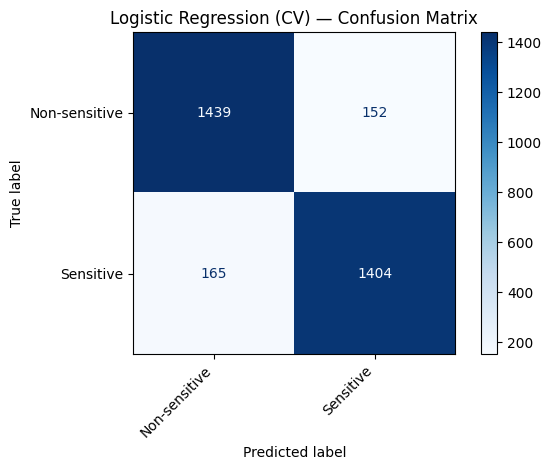


  Logistic Regression (CV)
  Accuracy:     89.97%
  Macro F1:     89.97%
  Weighted F1:  89.97%
  F1 Sensitive: 89.86%
  AUC-ROC:      95.26%

               precision    recall  f1-score   support

Non-sensitive       0.90      0.90      0.90      1591
    Sensitive       0.90      0.89      0.90      1569

     accuracy                           0.90      3160
    macro avg       0.90      0.90      0.90      3160
 weighted avg       0.90      0.90      0.90      3160



In [14]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Log-spaced C grid: small C = strong regularisation, large C = weak regularisation
Cs = np.logspace(-4, 4, 10)   # 10 values from 0.0001 to 10000

model_cv = LogisticRegressionCV(
    Cs=Cs,              # regularisation strengths to search
    cv=5,               # 5-fold cross-validation
    scoring='f1_macro', # optimise for macro F1
    max_iter=1000,
    random_state=42,
    n_jobs=-1,          # parallelise across all CPU cores
    verbose=1
)

print('Fitting LogisticRegressionCV...')
model_cv.fit(X_train, y_train)

print(f'\nBest C per class:   {model_cv.C_}')
print(f'Iterations used:    {model_cv.n_iter_}')

# mean CV score across folds for each C value (class 1 = Sensitive)
mean_scores = model_cv.scores_[1].mean(axis=1)
print(f'Best mean CV score: {mean_scores.max():.4f}')

y_pred_cv = model_cv.predict(X_test)
y_prob_cv = model_cv.predict_proba(X_test)[:, 1]

f1_cv = f1_score(y_test, y_pred_cv, average='macro')
print(f'\nTest F1 Macro: {f1_cv:.4f}')
print(f'Baseline LR F1: {f1_score(y_test, y_pred, average="macro"):.4f}')

cm_cv = confusion_matrix(y_test, y_pred_cv)
ConfusionMatrixDisplay(cm_cv, display_labels=le.classes_).plot(cmap='Blues')
plt.title('Logistic Regression (CV) — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

all_results.append(evaluate('Logistic Regression (CV)', y_test, y_pred_cv, y_prob_cv))

## 11. K-Nearest Neighbours with Grid Search

KNN with `GridSearchCV` over K, weighting scheme, and distance metric.
Included for completeness; expected to underperform LR/SVM on sparse BOW features.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Compact grid — odd K values avoid ties; cosine suits sparse high-dim BOW
param_grid = {
    'n_neighbors': [5, 11, 21, 31],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'cosine']
}

knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

knn_cv.fit(X_train, y_train)

print(f'Best Params: {knn_cv.best_params_}')
print(f'Best CV F1:  {knn_cv.best_score_:.4f}')

y_pred_knn = knn_cv.predict(X_test)
y_prob_knn = knn_cv.predict_proba(X_test)[:, 1]

all_results.append(evaluate('KNN', y_test, y_pred_knn, y_prob_knn))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'metric': 'cosine', 'n_neighbors': 31, 'weights': 'distance'}
Best CV F1:  0.8596

  KNN
  Accuracy:     86.01%
  Macro F1:     86.01%
  Weighted F1:  86.01%
  F1 Sensitive: 85.73%
  AUC-ROC:      93.18%

               precision    recall  f1-score   support

Non-sensitive       0.85      0.87      0.86      1591
    Sensitive       0.87      0.85      0.86      1569

     accuracy                           0.86      3160
    macro avg       0.86      0.86      0.86      3160
 weighted avg       0.86      0.86      0.86      3160



## 12. Linear SVM with L1/L2 Regularisation

> Add blockquote



`LinearSVC` with `GridSearchCV` over C and penalty type.
L1 penalty induces sparsity (useful for feature selection on BOW);
L2 is the standard Tikhonov regulariser. `LinearSVC` does not support
`predict_proba`, so AUC is not computed.

Fitting Linear SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'C': np.float64(0.046415888336127774), 'dual': False, 'penalty': 'l2'}
Best CV F1:      0.9096
Test F1 Macro:   0.9050


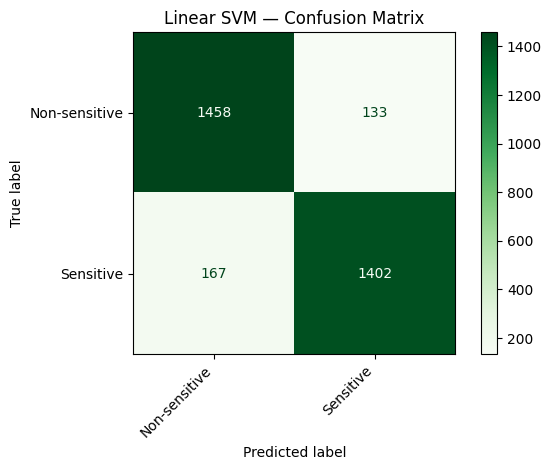


  SVM (LinearSVC)
  Accuracy:     90.51%
  Macro F1:     90.5%
  Weighted F1:  90.5%
  F1 Sensitive: 90.34%

               precision    recall  f1-score   support

Non-sensitive       0.90      0.92      0.91      1591
    Sensitive       0.91      0.89      0.90      1569

     accuracy                           0.91      3160
    macro avg       0.91      0.90      0.91      3160
 weighted avg       0.91      0.91      0.91      3160



In [16]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
import numpy as np

# Search over regularisation strength and penalty type
# L1 requires dual=False and produces a sparse weight vector
param_grid_linear = {
    'C':       np.logspace(-4, 4, 10),
    'penalty': ['l1', 'l2'],
    'dual':    [False]              # required when penalty='l1'
}

linear_svm = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid_linear,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print('Fitting Linear SVM...')
linear_svm.fit(X_train, y_train)

print(f'\nBest Parameters: {linear_svm.best_params_}')
print(f'Best CV F1:      {linear_svm.best_score_:.4f}')

y_pred_linear = linear_svm.predict(X_test)
print(f'Test F1 Macro:   {f1_score(y_test, y_pred_linear, average="macro"):.4f}')

cm_svm = confusion_matrix(y_test, y_pred_linear)
ConfusionMatrixDisplay(cm_svm, display_labels=le.classes_).plot(cmap='Greens')
plt.title('Linear SVM — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# LinearSVC has no predict_proba → pass None so AUC is skipped
all_results.append(evaluate('SVM (LinearSVC)', y_test, y_pred_linear, None))

Testing Linear SVM with L1/L2 Regularisation on synthetic data


In [17]:
# ── Synthetic data evaluation — SVM (LinearSVC) ───────────────────────────────
import pandas as pd

syn_df = pd.read_excel('syn_test_set.xlsx', header=0)
syn_df.columns = ['sentence', 'true_label']

# Encode true labels and vectorise
syn_true    = le.transform(syn_df['true_label'])
syn_bow     = vectorizer.transform(syn_df['sentence'])

# Predict
syn_preds   = linear_svm.predict(syn_bow)
syn_labels  = le.inverse_transform(syn_preds)

# Decision function scores — extract the winning class margin
scores      = linear_svm.decision_function(syn_bow)
syn_margins = scores[range(len(syn_preds)), syn_preds] if scores.ndim == 2 else scores

# Evaluate using the shared evaluate() function
# Note: LinearSVC has no predict_proba so y_prob=None → AUC skipped
all_results.append(evaluate('SVM (LinearSVC) — Synthetic Test Set',
                             syn_true, syn_preds, y_prob=None))

# Save to Colab file browser
output_path = '/content/svm_synthetic_predictions.xlsx'

pd.DataFrame({
    'sentence'                : syn_df['sentence'].values,
    'true_label'              : syn_df['true_label'].values,
    'predicted_label'         : syn_labels,
    'distance_from_hyperplane': syn_margins.round(4),  # ✅ margin, not probability
}).to_excel(output_path, index=False)

print(f'File saved to Colab at: {output_path}')


  SVM (LinearSVC) — Synthetic Test Set
  Accuracy:     87.5%
  Macro F1:     86.83%
  Weighted F1:  87.13%
  F1 Sensitive: 89.8%

               precision    recall  f1-score   support

Non-sensitive       1.00      0.72      0.84        18
    Sensitive       0.81      1.00      0.90        22

     accuracy                           0.88        40
    macro avg       0.91      0.86      0.87        40
 weighted avg       0.90      0.88      0.87        40

File saved to Colab at: /content/svm_synthetic_predictions.xlsx


## 13. Classical Models — Results Summary

Aggregated metrics for all BOW-based models, sorted by accuracy.

In [18]:
import pandas as pd

# Build comparison table from the results accumulated by evaluate()
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('f1_macro', ascending=False)  # rank by macro F1

print('\n' + '='*70)
print('CLASSICAL MODELS — FINAL RESULTS')
print('='*70)
print(results_df[['model','accuracy','f1_macro',
                   'f1_weighted','f1_sensitive','auc']].to_string(index=False))

# Persist results for report / downstream analysis
results_df.to_csv('spedac1_results_classical.csv', index=False)


CLASSICAL MODELS — FINAL RESULTS
                               model  accuracy  f1_macro  f1_weighted  f1_sensitive   auc
         Logistic Regression (no CV)     90.51     90.50        90.51         90.37 95.48
                     SVM (LinearSVC)     90.51     90.50        90.50         90.34   NaN
            Logistic Regression (CV)     89.97     89.97        89.97         89.86 95.26
     LR (no CV) — Synthetic Test Set     87.50     86.83        87.13         89.80 92.17
SVM (LinearSVC) — Synthetic Test Set     87.50     86.83        87.13         89.80   NaN
                                 KNN     86.01     86.01        86.01         85.73 93.18


## 14. Transformer Fine-Tuning

Four pre-trained transformers are fine-tuned on the same data:

| Model | Notes |
|---|---|
| `distilbert-base-uncased` | Lightweight, fast; good baseline transformer |
| `roberta-base` | Strong English encoder; typically best on classification |
| `sentence-transformers/LaBSE` | Multilingual sentence encoder; `ignore_mismatched_sizes=True` required |
| `microsoft/deberta-base` | Disentangled attention; strong on nuanced classification |

Each model uses a **separate** 70/30 stratified split on the raw text
(transformers use the original text, not the BOW-preprocessed version).
A 10% validation slice is carved from the training portion for early stopping.

In [19]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# ── Rebuild plain-text splits (same seed as training) ────────────────────────
text_series  = combined_df['text'].reset_index(drop=True)
label_series = combined_df['label_encoded'].reset_index(drop=True)

text_train, text_test, label_train, label_test = train_test_split(
    text_series, label_series,
    test_size=0.3, random_state=42, stratify=label_series
)
text_train, text_val, label_train, label_val = train_test_split(
    text_train, label_train,
    test_size=0.1, random_state=42, stratify=label_train
)

text_train  = text_train.reset_index(drop=True)
text_val    = text_val.reset_index(drop=True)
text_test   = text_test.reset_index(drop=True)
label_train = label_train.reset_index(drop=True)
label_val   = label_val.reset_index(drop=True)
label_test  = label_test.reset_index(drop=True)

# ── HuggingFace dataset helpers ───────────────────────────────────────────────
def make_hf_dataset(texts, labels, tokenizer, max_length=128):
    ds = Dataset.from_dict({'text': texts.tolist(), 'label': labels.tolist()})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_length)
    return ds.map(tokenize, batched=True)

def make_hf_dataset_unlabelled(texts, tokenizer, max_length=128):
    """Synthetic inference — dummy labels satisfy HF Dataset schema."""
    ds = Dataset.from_dict({'text': texts.tolist(),
                            'label': [0] * len(texts)})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_length)
    return ds.map(tokenize, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds) * 100, 2),
        'f1_macro': round(f1_score(labels, preds, average='macro',
                                   zero_division=0) * 100, 2)
    }

# ── Load synthetic test set once — reused for all models ─────────────────────
syn_df = pd.read_excel('syn_test_set.xlsx', header=0)
syn_df.columns = ['sentence', 'true_label']
syn_true = le.transform(syn_df['true_label'])

# ── Model registry ────────────────────────────────────────────────────────────
TRANSFORMER_MODELS = {
    'LaBSE': 'sentence-transformers/LaBSE',
}

# ── Training + evaluation loop ────────────────────────────────────────────────
for model_name, model_path in TRANSFORMER_MODELS.items():
    print(f"\n{'='*50}\nTraining {model_name}...\n{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tfr_model = AutoModelForSequenceClassification.from_pretrained(
                    model_path, num_labels=2,
                    ignore_mismatched_sizes=True)

    train_ds = make_hf_dataset(text_train, label_train, tokenizer)
    val_ds   = make_hf_dataset(text_val,   label_val,   tokenizer)
    test_ds  = make_hf_dataset(text_test,  label_test,  tokenizer)

    args = TrainingArguments(
        output_dir                  = f'./results/{model_name}',
        learning_rate               = 3e-5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        num_train_epochs            = 3,
        weight_decay                = 0.01,
        eval_strategy               = 'epoch',
        save_strategy               = 'no',
        load_best_model_at_end      = False,
        metric_for_best_model       = 'f1_macro',
        logging_steps               = 50,
        fp16                        = torch.cuda.is_available(),
        seed                        = 42,
    )

    trainer = Trainer(
        model           = tfr_model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
    )

    trainer.train()

    # ── Standard held-out test evaluation ────────────────────────────────────
    preds_output = trainer.predict(test_ds)
    logits       = preds_output.predictions
    y_pred_tr    = np.argmax(logits, axis=-1)
    y_prob_tr    = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    all_results.append(evaluate(model_name, label_test, y_pred_tr, y_prob_tr))
    print(f'  Done — {model_name} results saved.')

    # ── Synthetic data evaluation ─────────────────────────────────────────────
    syn_ds        = make_hf_dataset_unlabelled(syn_df['sentence'], tokenizer)
    syn_output    = trainer.predict(syn_ds)
    syn_logits    = syn_output.predictions
    syn_preds     = np.argmax(syn_logits, axis=-1)
    syn_labels    = le.inverse_transform(syn_preds)

    # Softmax probability of the predicted class
    syn_probs_all = torch.softmax(torch.tensor(syn_logits), dim=-1)
    syn_probs     = syn_probs_all[range(len(syn_preds)), syn_preds].numpy()

    # Evaluate using the shared evaluate() function
    all_results.append(evaluate(f'{model_name} — Synthetic Test Set',
                                syn_true, syn_preds, syn_probs))

    # Save to Colab file browser
    output_path = f'/content/{model_name}_synthetic_predictions.xlsx'
    pd.DataFrame({
        'sentence'              : syn_df['sentence'].values,
        'true_label'            : syn_df['true_label'].values,
        'predicted_label'       : syn_labels,
        'predicted_probability' : syn_probs.round(4),
    }).to_excel(output_path, index=False)

    print(f'  Synthetic predictions saved to Colab at: {output_path}')


Training LaBSE...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/3160 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.159500,0.179255,94.040000,94.040000
2,0.089041,0.191416,94.310000,94.310000
3,0.063809,0.207047,94.580000,94.580000



  LaBSE
  Accuracy:     96.04%
  Macro F1:     96.04%
  Weighted F1:  96.04%
  F1 Sensitive: 96.09%
  AUC-ROC:      98.81%

               precision    recall  f1-score   support

Non-sensitive       0.98      0.94      0.96      1591
    Sensitive       0.94      0.98      0.96      1569

     accuracy                           0.96      3160
    macro avg       0.96      0.96      0.96      3160
 weighted avg       0.96      0.96      0.96      3160

  Done — LaBSE results saved.


Map:   0%|          | 0/40 [00:00<?, ? examples/s]


  LaBSE — Synthetic Test Set
  Accuracy:     82.5%
  Macro F1:     81.07%
  Weighted F1:  81.59%
  F1 Sensitive: 86.27%
  AUC-ROC:      64.65%

               precision    recall  f1-score   support

Non-sensitive       1.00      0.61      0.76        18
    Sensitive       0.76      1.00      0.86        22

     accuracy                           0.82        40
    macro avg       0.88      0.81      0.81        40
 weighted avg       0.87      0.82      0.82        40

  Synthetic predictions saved to Colab at: /content/LaBSE_synthetic_predictions.xlsx


In [20]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# ── Rebuild plain-text splits (same seed as training) ────────────────────────
text_series  = combined_df['text'].reset_index(drop=True)
label_series = combined_df['label_encoded'].reset_index(drop=True)

text_train, text_test, label_train, label_test = train_test_split(
    text_series, label_series,
    test_size=0.3, random_state=42, stratify=label_series
)
text_train, text_val, label_train, label_val = train_test_split(
    text_train, label_train,
    test_size=0.1, random_state=42, stratify=label_train
)

text_train  = text_train.reset_index(drop=True)
text_val    = text_val.reset_index(drop=True)
text_test   = text_test.reset_index(drop=True)
label_train = label_train.reset_index(drop=True)
label_val   = label_val.reset_index(drop=True)
label_test  = label_test.reset_index(drop=True)

# ── HuggingFace dataset helpers ───────────────────────────────────────────────
def make_hf_dataset(texts, labels, tokenizer, max_length=128):
    ds = Dataset.from_dict({'text': texts.tolist(), 'label': labels.tolist()})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_length)
    return ds.map(tokenize, batched=True)

def make_hf_dataset_unlabelled(texts, tokenizer, max_length=128):
    """Synthetic inference — dummy labels satisfy HF Dataset schema."""
    ds = Dataset.from_dict({'text': texts.tolist(),
                            'label': [0] * len(texts)})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_length)
    return ds.map(tokenize, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds) * 100, 2),
        'f1_macro': round(f1_score(labels, preds, average='macro',
                                   zero_division=0) * 100, 2)
    }

# ── Load synthetic test set once ─────────────────────────────────────────────
syn_df = pd.read_excel('syn_test_set.xlsx', header=0)
syn_df.columns = ['sentence', 'true_label']
syn_true = le.transform(syn_df['true_label'])

# ── Model registry ────────────────────────────────────────────────────────────
TRANSFORMER_MODELS = {
    'RoBERTa': 'roberta-base',          # ✅ only change from LaBSE cell
}

# ── Training + evaluation loop ────────────────────────────────────────────────
for model_name, model_path in TRANSFORMER_MODELS.items():
    print(f"\n{'='*50}\nTraining {model_name}...\n{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tfr_model = AutoModelForSequenceClassification.from_pretrained(
                    model_path, num_labels=2,
                    ignore_mismatched_sizes=True)

    train_ds = make_hf_dataset(text_train, label_train, tokenizer)
    val_ds   = make_hf_dataset(text_val,   label_val,   tokenizer)
    test_ds  = make_hf_dataset(text_test,  label_test,  tokenizer)

    args = TrainingArguments(
        output_dir                  = f'./results/{model_name}',
        learning_rate               = 3e-5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        num_train_epochs            = 3,
        weight_decay                = 0.01,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_macro',
        logging_steps               = 50,
        fp16                        = torch.cuda.is_available(),
        seed                        = 42,
    )

    trainer = Trainer(
        model           = tfr_model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
    )

    trainer.train()

    # ── Standard held-out test evaluation ────────────────────────────────────
    preds_output = trainer.predict(test_ds)
    logits       = preds_output.predictions
    y_pred_tr    = np.argmax(logits, axis=-1)
    y_prob_tr    = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    all_results.append(evaluate(model_name, label_test, y_pred_tr, y_prob_tr))
    print(f'  Done — {model_name} results saved.')

    # ── Synthetic data evaluation ─────────────────────────────────────────────
    syn_ds        = make_hf_dataset_unlabelled(syn_df['sentence'], tokenizer)
    syn_output    = trainer.predict(syn_ds)
    syn_logits    = syn_output.predictions
    syn_preds     = np.argmax(syn_logits, axis=-1)
    syn_labels    = le.inverse_transform(syn_preds)

    # Softmax probability of the predicted class
    syn_probs_all = torch.softmax(torch.tensor(syn_logits), dim=-1)
    syn_probs     = syn_probs_all[range(len(syn_preds)), syn_preds].numpy()

    # Evaluate using the shared evaluate() function
    all_results.append(evaluate(f'{model_name} — Synthetic Test Set',
                                syn_true, syn_preds, syn_probs))

    # Save to Colab file browser
    output_path = f'/content/{model_name}_synthetic_predictions.xlsx'  # ✅ roberta_synthetic_predictions.xlsx
    pd.DataFrame({
        'sentence'              : syn_df['sentence'].values,
        'true_label'            : syn_df['true_label'].values,
        'predicted_label'       : syn_labels,
        'predicted_probability' : syn_probs.round(4),
    }).to_excel(output_path, index=False)

    print(f'  Synthetic predictions saved to Colab at: {output_path}')


Training RoBERTa...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  RoBERTa
  Accuracy:     95.66%
  Macro F1:     95.66%
  Weighted F1:  95.66%
  F1 Sensitive: 95.74%
  AUC-ROC:      98.54%

               precision    recall  f1-score   support

Non-sensitive       0.98      0.93      0.96      1591
    Sensitive       0.94      0.98      0.96      1569

     accuracy                           0.96      3160
    macro avg       0.96      0.96      0.96      3160
 weighted avg       0.96      0.96      0.96      3160

  Done — RoBERTa results saved.


Map:   0%|          | 0/40 [00:00<?, ? examples/s]


  RoBERTa — Synthetic Test Set
  Accuracy:     80.0%
  Macro F1:     78.02%
  Weighted F1:  78.68%
  F1 Sensitive: 84.62%
  AUC-ROC:      54.55%

               precision    recall  f1-score   support

Non-sensitive       1.00      0.56      0.71        18
    Sensitive       0.73      1.00      0.85        22

     accuracy                           0.80        40
    macro avg       0.87      0.78      0.78        40
 weighted avg       0.85      0.80      0.79        40

  Synthetic predictions saved to Colab at: /content/RoBERTa_synthetic_predictions.xlsx


In [21]:
import torch
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# ── Rebuild plain-text splits ────────────────────────────────────────────────
# Transformers need raw text, not BOW vectors. We re-split combined_df with
# the same seed/strategy as the classical split so results are comparable.
text_series  = combined_df['text'].reset_index(drop=True)
label_series = combined_df['label_encoded'].reset_index(drop=True)

# Primary 70/30 split
text_train, text_test, label_train, label_test = train_test_split(
    text_series, label_series,
    test_size=0.3, random_state=42, stratify=label_series
)

# Carve a validation set from the training portion (10% of original total)
# Used for eval_strategy='epoch' and load_best_model_at_end
text_train, text_val, label_train, label_val = train_test_split(
    text_train, label_train,
    test_size=0.1, random_state=42, stratify=label_train
)

# Reset indices — HF Dataset.from_dict requires contiguous 0-based indices
text_train  = text_train.reset_index(drop=True)
text_val    = text_val.reset_index(drop=True)
text_test   = text_test.reset_index(drop=True)
label_train = label_train.reset_index(drop=True)
label_val   = label_val.reset_index(drop=True)
label_test  = label_test.reset_index(drop=True)

# ── HuggingFace dataset helper ───────────────────────────────────────────────
def make_hf_dataset(texts, labels, tokenizer, max_length=128):
    """
    Convert a text Series + label Series into a tokenised HF Dataset.
    max_length=128 covers the 95th percentile of sentence lengths (see Section 4).
    """
    ds = Dataset.from_dict({'text': texts.tolist(), 'label': labels.tolist()})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_length)
    return ds.map(tokenize, batched=True)

def compute_metrics(eval_pred):
    """Called by Trainer after each eval epoch to report accuracy and macro F1."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds) * 100, 2),
        'f1_macro': round(f1_score(labels, preds, average='macro',
                                   zero_division=0) * 100, 2)
    }

# ── Model registry ───────────────────────────────────────────────────────────
TRANSFORMER_MODELS = {
    'DistilBERT':   'distilbert-base-uncased',
    'DeBERTa-base': 'microsoft/deberta-base',
}

# ── Training loop ────────────────────────────────────────────────────────────
for model_name, model_path in TRANSFORMER_MODELS.items():
    print(f"\n{'='*50}\nTraining {model_name}...\n{'='*50}")

    # Load tokenizer and add a 2-class classification head
    # ignore_mismatched_sizes=True is required for LaBSE whose pooler
    # dimensions differ from the randomly initialised classification head
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tfr_model     = AutoModelForSequenceClassification.from_pretrained(
                    model_path, num_labels=2,
                    ignore_mismatched_sizes=True)

    train_ds = make_hf_dataset(text_train, label_train, tokenizer)
    val_ds   = make_hf_dataset(text_val,   label_val,   tokenizer)
    test_ds  = make_hf_dataset(text_test,  label_test,  tokenizer)

    args = TrainingArguments(
    output_dir                  = f'./results/{model_name}',
    learning_rate               = 3e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    num_train_epochs            = 3,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available() and model_name != 'DeBERTa-base',  # fp16 breaks DeBERTa
    seed                        = 42,
)

    trainer = Trainer(
        model           = tfr_model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
    )

    trainer.train()

    # ── Inference on test set ────────────────────────────────────────────────
    preds_output = trainer.predict(test_ds)
    logits       = preds_output.predictions
    y_pred_tr    = np.argmax(logits, axis=-1)
    # Convert logits to probabilities; take col-1 for the Sensitive class
    y_prob_tr    = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    # label_test is a clean 0-indexed Series aligned with test_ds
    all_results.append(evaluate(model_name, label_test, y_pred_tr, y_prob_tr))
    print(f'  Done — {model_name} results saved.')



Training DistilBERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.174963,0.206989,93.630000,93.630000
2,0.148294,0.203562,93.900000,93.900000
3,0.108702,0.216523,94.040000,94.040000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


  DeBERTa-base
  Accuracy:     95.0%
  Macro F1:     95.0%
  Weighted F1:  95.0%
  F1 Sensitive: 95.08%
  AUC-ROC:      98.61%

               precision    recall  f1-score   support

Non-sensitive       0.97      0.93      0.95      1591
    Sensitive       0.93      0.97      0.95      1569

     accuracy                           0.95      3160
    macro avg       0.95      0.95      0.95      3160
 weighted avg       0.95      0.95      0.95      3160

  Done — DeBERTa-base results saved.


In [22]:
# ── Final combined results — all models ──────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('f1_macro', ascending=False)
print('\n' + '='*70)
print('ALL MODELS — FINAL RESULTS')
print('='*70)
print(results_df[['model','accuracy','f1_macro',
                   'f1_weighted','f1_sensitive','auc']].to_string(index=False))
results_df.to_csv('spedac1_results_all.csv', index=False)


ALL MODELS — FINAL RESULTS
                               model  accuracy  f1_macro  f1_weighted  f1_sensitive   auc
                               LaBSE     96.04     96.04        96.04         96.09 98.81
                             RoBERTa     95.66     95.66        95.66         95.74 98.54
                          DistilBERT     95.44     95.44        95.44         95.53 98.44
                        DeBERTa-base     95.00     95.00        95.00         95.08 98.61
                     SVM (LinearSVC)     90.51     90.50        90.50         90.34   NaN
         Logistic Regression (no CV)     90.51     90.50        90.51         90.37 95.48
            Logistic Regression (CV)     89.97     89.97        89.97         89.86 95.26
     LR (no CV) — Synthetic Test Set     87.50     86.83        87.13         89.80 92.17
SVM (LinearSVC) — Synthetic Test Set     87.50     86.83        87.13         89.80   NaN
                                 KNN     86.01     86.01        86.01   

In [24]:
def colab2pdf():
  ENABLE=True # @param {type:"boolean"}
  if ENABLE:
    !apt-get install librsvg2-bin
    import os, datetime, json, locale, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions").json()[0]["name"])))
    TEMP = pathlib.Path("/content/pdfs") / f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{NAME.stem}"; TEMP.mkdir(parents=True, exist_ok=True)
    NB = [cell for cell in nbformat.reads(json.dumps(google.colab._message.blocking_request("get_ipynb", timeout_sec=600)["ipynb"]), as_version=4).cells if "--Colab2PDF" not in cell.source]
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    with (TEMP / f"{NAME.stem}.ipynb").open("w", encoding="utf-8") as nb_copy: nbformat.write(nbformat.v4.new_notebook(cells=NB or [nbformat.v4.new_code_cell("#")]), nb_copy)
  if not pathlib.Path("/usr/local/bin/quarto").exists():
    !wget -q "https://quarto.org/download/latest/quarto-linux-amd64.deb" -P {TEMP} && dpkg -i {TEMP}/quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet
    with (TEMP / "config.yml").open("w", encoding="utf-8") as file: yaml.dump({'include-in-header': [{"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}],'include-before-body': [{"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}]}, file)
    !quarto render {TEMP}/{NAME.stem}.ipynb --metadata-file={TEMP}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
    google.colab.files.download(str(TEMP / f"{NAME.stem}.pdf"))
colab2pdf()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
librsvg2-bin is already the newest version (2.52.5+dfsg-3ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


NotebookValidationError: Additional properties are not allowed ('metadata' was unexpected)

Failed validating 'additionalProperties' in stream:

On instance['cells'][37]['outputs'][0]:
{'metadata': {'tags': None},
 'name': 'stdout',
 'output_type': 'stream',
 'text': '\n'
         '==================================================\n'
         'Training Dis...'}